In [75]:
import pandas as pd
import numpy as np

print('✅ Ready')

✅ Ready


In [76]:
#Lets load the data

df_2009 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010', engine='openpyxl')
df_2010 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011', engine='openpyxl')

print(f'2009-2010 shape: {df_2009.shape}')
print(f'2010-2011 shape: {df_2010.shape}')

2009-2010 shape: (525461, 8)
2010-2011 shape: (541910, 8)


In [77]:
df_2009.shape

(525461, 8)

In [78]:
#Now lets concat both tables in to one

df_raw = pd.concat([df_2009, df_2010], ignore_index=True)

print(f'Combined shape: {df_raw.shape}')

Combined shape: (1067371, 8)


In [79]:
print(df_raw.shape)
df_raw.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


all 5 rows have the same Invoice number (489434) and the same Customer ID (13085).   
This means one customer placed one order containing multiple products. Each product is its own row.  
this is a transaction-level data — one row per product per order, not one row per customer.

In [80]:
# handle missing values
print(df_raw.dtypes)
print('\nMissing values:')
print(df_raw.isnull().sum())

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


Only the "Dscription" and "Customer_ID" columns have some missing values 

Problem 1 — Description has 4,382 missing values  
Some product lines have no description. This is not critical —   
we don't use the description column in our analysis. We can ignore this.

Problem 2 — Customer ID has 243,007 missing values  
This is a big problem. 243,007 rows have no customer attached to them.   
We have no idea who made these purchases. Since our entire project is about understanding individual customers,   
these rows are useless to us — we'll remove them.

In [81]:
#Lets check whats the data looks like

print(f'Total rows before cleaning : {len(df_raw):,}')
print(f'Rows with no Customer ID   : {df_raw["Customer ID"].isnull().sum():,}')
print(f'Unique customers           : {df_raw["Customer ID"].nunique():,}')
print(f'Unique invoices            : {df_raw["Invoice"].nunique():,}')

Total rows before cleaning : 1,067,371
Rows with no Customer ID   : 243,007
Unique customers           : 5,942
Unique invoices            : 53,628


1,067,371 total rows  
243,007 rows we'll remove — no customer ID  
5,942 unique customers — these are the people we're analysing  
53,628 unique invoices — meaning on average each customer placed about 9 orders  

In [82]:
# Frst clean - remove rows with no customer ID:

df = df_raw.dropna(subset=['Customer ID'])

print(f'Rows before : {len(df_raw):,}')
print(f'Rows after  : {len(df):,}')
print(f'Rows removed: {len(df_raw) - len(df):,}')

Rows before : 1,067,371
Rows after  : 824,364
Rows removed: 243,007


Some invoices start with the letter 'C' — these are cancellations or returns.  
 A customer ordered something and then sent it back.   
 We don't want to count these as real purchases.

In [83]:
# Show invoices that start with 'C'
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]

print(f'Cancelled invoices : {len(cancelled):,}')
print(f'Example cancelled invoices:')
print(cancelled.head())

Cancelled invoices : 18,744
Example cancelled invoices:
     Invoice StockCode                    Description  Quantity  \
178  C489449     22087       PAPER BUNTING WHITE LACE       -12   
179  C489449    85206A   CREAM FELT EASTER EGG BASKET        -6   
180  C489449     21895  POTTING SHED SOW 'N' GROW SET        -4   
181  C489449     21896             POTTING SHED TWINE        -6   
182  C489449     22083     PAPER CHAIN KIT RETRO SPOT       -12   

            InvoiceDate  Price  Customer ID    Country  
178 2009-12-01 10:33:00   2.95      16321.0  Australia  
179 2009-12-01 10:33:00   1.65      16321.0  Australia  
180 2009-12-01 10:33:00   4.25      16321.0  Australia  
181 2009-12-01 10:33:00   2.10      16321.0  Australia  
182 2009-12-01 10:33:00   2.95      16321.0  Australia  


In [84]:
# remove cancelled orders

df = df[~df['Invoice'].astype(str).str.startswith('C')]

print(f'Rows after removing cancellations: {len(df):,}')

Rows after removing cancellations: 805,620


A transaction should always have a positive quantity and a positive price.  
If someone bought 0 items or paid £0, something is wrong with the data — either a data entry error or a system glitch.   
We should remove those rows

In [85]:
print(f'Rows with zero or negative quantity : {(df["Quantity"] <= 0).sum():,}')
print(f'Rows with zero or negative price    : {(df["Price"] <= 0).sum():,}')

Rows with zero or negative quantity : 0
Rows with zero or negative price    : 71


In [86]:
# remove those rows with qty. or price <= 0
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

print(f'Rows after removing invalid prices: {len(df):,}')


Rows after removing invalid prices: 805,549


Lets check for non product stock codes  
Not every row in the dataset is a real product sale.  
Some rows represent postage charges, bank fees, manual adjustments etc.   
These are accounting entries

In [87]:
non_product = ['POST', 'D', 'M', 'BANK CHARGES', 'PADS', 'DOT']

mask = df['StockCode'].astype(str).str.upper().isin(non_product)

print(f'Non-product rows found: {mask.sum():,}')
print(df[mask]['StockCode'].value_counts())

Non-product rows found: 2,617
StockCode
POST            1838
M                709
BANK CHARGES      32
PADS              17
DOT               16
D                  5
Name: count, dtype: int64


In [88]:
# Now lets remove non product entries

df = df[~df['StockCode'].astype(str).str.upper().isin(non_product)]

print(f'Rows after removing non-products: {len(df):,}')

Rows after removing non-products: 802,932


Lets look at a summary of everything we just cleaned

In [89]:
print('── Cleaning Summary ──────────────────')
print(f'Raw data           : {len(df_raw):>10,} rows')
print(f'Missing Customer ID: {len(df_raw) - 824364:>10,} rows removed')
print(f'Cancellations      : {824364 - 805620:>10,} rows removed')
print(f'Invalid prices     : {805620 - 805549:>10,} rows removed')
print(f'Non-product rows   : {805549 - 802932:>10,} rows removed')
print(f'──────────────────────────────────────')
print(f'Clean data         : {len(df):>10,} rows')
print(f'Total removed      : {len(df_raw) - len(df):>10,} rows')
print(f'Data retained      : {len(df)/len(df_raw)*100:>9.1f}%')

── Cleaning Summary ──────────────────
Raw data           :  1,067,371 rows
Missing Customer ID:    243,007 rows removed
Cancellations      :     18,744 rows removed
Invalid prices     :         71 rows removed
Non-product rows   :      2,617 rows removed
──────────────────────────────────────
Clean data         :    802,932 rows
Total removed      :    264,439 rows
Data retained      :      75.2%


In [90]:
df.shape

(802932, 8)

In [91]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [92]:
# Fix data types and add some more columns as data pre processing steps

# Fix Customer ID — remove the decimal point (13085.0 → 13085)
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)

# Parse InvoiceDate as a proper datetime so we can do date calculations
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Add a total price column — quantity × price per unit
df['TotalPrice'] = df['Quantity'] * df['Price']

print(df[['Customer ID', 'InvoiceDate', 'TotalPrice']].head())
print(f'\nData types:')
print(df[['Customer ID', 'InvoiceDate', 'TotalPrice']].dtypes)

  Customer ID         InvoiceDate  TotalPrice
0       13085 2009-12-01 07:45:00        83.4
1       13085 2009-12-01 07:45:00        81.0
2       13085 2009-12-01 07:45:00        81.0
3       13085 2009-12-01 07:45:00       100.8
4       13085 2009-12-01 07:45:00        30.0

Data types:
Customer ID            object
InvoiceDate    datetime64[ns]
TotalPrice            float64
dtype: object


In [93]:
print(f'Clean dataset shape  : {df.shape}')
print(f'Unique customers     : {df["Customer ID"].nunique():,}')
print(f'Unique invoices      : {df["Invoice"].nunique():,}')
print(f'Date range           : {df["InvoiceDate"].min().date()}  →  {df["InvoiceDate"].max().date()}')
print(f'Total revenue        : £{df["TotalPrice"].sum():,.2f}')
print(f'Avg order value      : £{df.groupby("Invoice")["TotalPrice"].sum().mean():,.2f}')

Clean dataset shape  : (802932, 9)
Unique customers     : 5,862
Unique invoices      : 36,645
Date range           : 2009-12-01  →  2011-12-09
Total revenue        : £17,451,756.30
Avg order value      : £476.24


What this dataset represents:
This is a UK-based wholesale retailer. Their customers are businesses — gift shops, boutiques,  
online resellers — who buy products in bulk and then resell them to end consumers.  

So when we see a row like:
Customer 13085 bought 12 units of "15CM CHRISTMAS GLASS BALL" at £6.95 each  
That's not an individual person buying one Christmas ornament for their home.  
That's a shop owner buying 12 of them to stock their shelves and sell individually to their customers at a higher price.  

This explains why the average order value was £476 — shops buy in bulk, not single items.  
It also explains the October/November revenue peak —   
shop owners are stocking up their shelves for the Christmas retail season so their customers can buy gifts.

In [94]:
df.shape
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


Now Data cleaning and preprocessing is done.   
Lets start EDA

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
print('✅ Plotting libraries ready')

✅ Plotting libraries ready


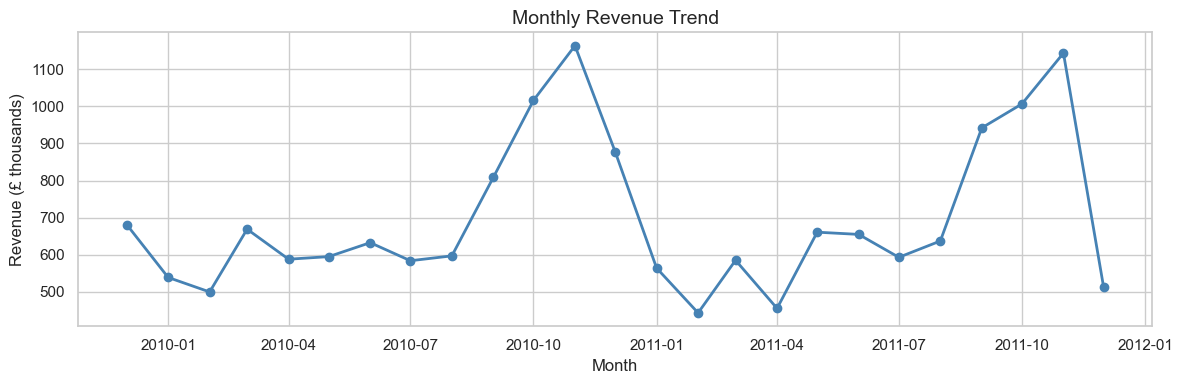

In [96]:
# Group total revenue by year and month
monthly_rev = df.groupby([df['InvoiceDate'].dt.year, df['InvoiceDate'].dt.month])['TotalPrice'].sum()
monthly_rev.index.names = ['Year', 'Month']
monthly_rev = monthly_rev.reset_index()

# Create a proper date column for the x-axis
monthly_rev['Period'] = pd.to_datetime(
    monthly_rev['Year'].astype(str) + '-' + monthly_rev['Month'].astype(str)
)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(monthly_rev['Period'], monthly_rev['TotalPrice'] / 1000, marker='o', linewidth=2, color='steelblue')
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (£ thousands)')
plt.tight_layout()
plt.show()

In [97]:
# Lets get a breakdown of monthly revenue

monthly_rev['Revenue'] = monthly_rev['TotalPrice'].round(2)
monthly_rev['Revenue_pct'] = (monthly_rev['Revenue'] / monthly_rev['Revenue'].sum() * 100).round(1)

print(f'{"Year":<6} {"Month":<8} {"Revenue (£)":>15} {"% of Total":>12}')
print('─' * 45)
for _, row in monthly_rev.iterrows():
    print(f'{int(row["Year"]):<6} {int(row["Month"]):<8} £{row["Revenue"]:>14,.2f} {row["Revenue_pct"]:>11.1f}%')

print('─' * 45)
print(f'{"TOTAL":<15} £{monthly_rev["Revenue"].sum():>14,.2f} {"100.0%":>12}')

Year   Month        Revenue (£)   % of Total
─────────────────────────────────────────────
2009   12       £    681,529.72         3.9%
2010   1        £    539,007.89         3.1%
2010   2        £    499,949.68         2.9%
2010   3        £    668,977.19         3.8%
2010   4        £    588,126.27         3.4%
2010   5        £    595,086.54         3.4%
2010   6        £    632,685.90         3.6%
2010   7        £    584,048.53         3.3%
2010   8        £    597,129.22         3.4%
2010   9        £    808,545.06         4.6%
2010   10       £  1,015,989.49         5.8%
2010   11       £  1,163,154.41         6.7%
2010   12       £    877,814.47         5.0%
2011   1        £    564,226.64         3.2%
2011   2        £    443,546.02         2.5%
2011   3        £    585,262.85         3.4%
2011   4        £    455,666.91         2.6%
2011   5        £    660,917.90         3.8%
2011   6        £    654,932.56         3.8%
2011   7        £    593,231.90         3.4%
2011   8 

October and November are consistently the strongest months — likely driven by businesses stocking up for Christmas.   
Remember this is a wholesale retailer, so their customers are shops buying inventory ahead of the holiday season.

Weakest months — January and February
After the Christmas rush, revenue drops sharply. January and February are consistently the lowest months —   
businesses have already stocked up and are selling through their inventory.

December 2011 looks low (£513,380)
This is because the dataset ends on 9th December 2011 — we only have 9 days of December data,  
not a full month. So it's not actually a slow month — just incomplete data.

The pattern repeats itself perfectly across both years — same peaks, same troughs.   
This tells us the business is very seasonal and predictable.

In [98]:
# Lets do a country wise breakdown of sales

country_revenue = (
    df.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
country_revenue.columns = ['Country', 'Revenue']
country_revenue['Revenue_pct'] = (country_revenue['Revenue'] / country_revenue['Revenue'].sum() * 100).round(1)

print(f'Total unique countries: {len(country_revenue)}')
print()
print(f'{"Country":<25} {"Revenue (£)":>15} {"% of Total":>12}')
print('─' * 55)
for _, row in country_revenue.iterrows():
    print(f'{row["Country"]:<25} £{row["Revenue"]:>14,.2f} {row["Revenue_pct"]:>11.1f}%')

Total unique countries: 41

Country                       Revenue (£)   % of Total
───────────────────────────────────────────────────────
United Kingdom            £ 14,627,419.25        83.8%
EIRE                      £    602,058.00         3.4%
Netherlands               £    549,952.66         3.2%
Germany                   £    388,959.99         2.2%
France                    £    315,714.40         1.8%
Australia                 £    168,484.66         1.0%
Spain                     £     98,840.54         0.6%
Switzerland               £     93,624.34         0.5%
Sweden                    £     86,079.04         0.5%
Denmark                   £     68,560.19         0.4%
Belgium                   £     57,322.77         0.3%
Portugal                  £     48,205.76         0.3%
Japan                     £     47,138.39         0.3%
Channel Islands           £     44,703.76         0.3%
Norway                    £     42,362.48         0.2%
Italy                     £     29,3

The country column tells you where that business customer is located. So:

United Kingdom — UK-based shops buying from this wholesaler  
Germany — German shops buying from this UK wholesaler  
France — French shops buying from this UK wholesaler  
And so on  


United Kingdom completely dominates — 83.8% of all revenue  
£14.6 million out of £17.4 million total comes from UK-based businesses.   
This makes sense — it's a UK wholesaler, so most of their customers are local UK shops.

                                                            **Lets do the RFM Analysis**

In [99]:
#Lets fix the Snapshot date (The date of Observation - In this case the Last date +1)

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f'Last transaction date : {df["InvoiceDate"].max().date()}')
print(f'Snapshot date         : {snapshot_date.date()}')

Last transaction date : 2011-12-09
Snapshot date         : 2011-12-10


In [100]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [101]:
# For each customer, find their most recent purchase date
last_purchase = df.groupby('Customer ID')['InvoiceDate'].max()

# Recency = number of days between their last purchase and snapshot date
recency = (snapshot_date - last_purchase).dt.days

print('Recency (days since last purchase):')
print(recency.describe().round(1))

Recency (days since last purchase):
count    5862.0
mean      201.0
std       209.2
min         1.0
25%        26.0
50%        96.0
75%       379.0
max       739.0
Name: InvoiceDate, dtype: float64


5,862 customers — matches our earlier count, good.  
Average recency — 201 days  
On average customers last bought 201 days ago. That's about 6.5 months — quite a long time.  
Minimum — 1 day  
Some customers bought just yesterday (relative to snapshot date). These are your most active customers.  
Median (50%) — 96 days  
Half of all customers last bought within 96 days. The other half haven't bought in over 96 days.  
75% — 379 days  
A quarter of customers haven't bought in over a year. These are likely lost/dormant.  
Maximum — 739 days  
Some customers bought once nearly 2 years ago and never came back.  

The big gap between median (96) and mean (201) tells us:  
Most customers are reasonably active, but there's a long tail of customers who bought a long time ago and dragged the average up.  
This is very typical in retail.

In [102]:
last_purchase.head()

Customer ID
12346   2011-01-18 10:01:00
12347   2011-12-07 15:52:00
12348   2011-09-25 13:13:00
12349   2011-11-21 09:51:00
12350   2011-02-02 16:01:00
Name: InvoiceDate, dtype: datetime64[ns]

In [103]:
recency.head()

Customer ID
12346    326
12347      2
12348     75
12349     19
12350    310
Name: InvoiceDate, dtype: int64

In [104]:
# Now lets calculate frequency for each customer

# Frequency = number of distinct invoices per customer
frequency = df.groupby('Customer ID')['Invoice'].nunique()

print('Frequency (number of orders):')
print(frequency.describe().round(1))

Frequency (number of orders):
count    5862.0
mean        6.3
std        12.8
min         1.0
25%         1.0
50%         3.0
75%         7.0
max       378.0
Name: Invoice, dtype: float64


Average frequency — 6.3 orders  
On average each customer placed about 6 orders over two years.  
Minimum — 1 order  
Many customers bought only once. These are one-time buyers.  
Median (50%) — 3 orders  
Half of all customers placed 3 or fewer orders. The typical customer is not highly frequent.  
75% — 7 orders  
Three quarters of customers placed 7 or fewer orders.  
Maximum — 378 orders  
One customer placed 378 orders over two years — that's almost every single day.   
This is almost certainly a large business buying regularly in bulk.

The big gap between median (3) and maximum (378) tells us:  
Most customers buy occasionally, but a small number of very active business buyers are placing orders constantly.   
This is very typical in wholesale — a handful of large business accounts drive a huge portion of order volume.

In [105]:
# Lets calculate monetary value for each customer

# Monetary = average order value per customer
monetary = df.groupby('Customer ID')['TotalPrice'].sum() / frequency

print('Monetary (average order value £):')
print(monetary.describe().round(2))

Monetary (average order value £):
count     5862.00
mean       387.22
std       1212.33
min          2.95
25%        179.77
50%        283.45
75%        418.06
max      84236.25
dtype: float64


Average order value — £387  
On average each customer spends £387 per order. Again confirming this is a wholesale business — consumers don't spend £387 per shopping trip.  
Minimum — £2.95  
Some customers place very small orders. Possibly small shops buying just a few items to test products.  
Median (50%) — £283  
Half of all customers spend less than £283 per order.  
75% — £418  
Three quarters of customers spend less than £418 per order.  
Maximum — £84,236  
One customer's average order is £84,236. This is a very large business account — possibly a chain of shops buying huge quantities regularly.  

The standard deviation is £1,212 — much larger than the mean of £387. This means spending varies enormously across customers.   
Some spend a few pounds, some spend tens of thousands.   
This wide spread is exactly why CLV modelling is valuable — you need to treat these customers very differently.

In [106]:
# Now Lets bring all three metrics in to one table

# Combine R, F, M into one dataframe
rfm = pd.DataFrame({
    'Recency'   : recency,
    'Frequency' : frequency,
    'Monetary'  : monetary,
})

rfm.index.name = 'Customer ID'
rfm.reset_index(inplace=True)

print(f'RFM table shape: {rfm.shape}')
rfm.head(10)

RFM table shape: (5862, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,6463.038333
1,12347,2,8,704.165000
2,12348,75,5,331.680000
3,12349,19,3,1226.230000
4,12350,310,1,294.400000
5,12351,375,1,300.930000
6,12352,36,9,192.171111
7,12353,204,2,203.380000
8,12354,232,1,1079.400000
9,12355,214,2,473.805000


In [107]:
monetary.head(10)

Customer ID
12346    6463.038333
12347     704.165000
12348     331.680000
12349    1226.230000
12350     294.400000
12351     300.930000
12352     192.171111
12353     203.380000
12354    1079.400000
12355     473.805000
dtype: float64

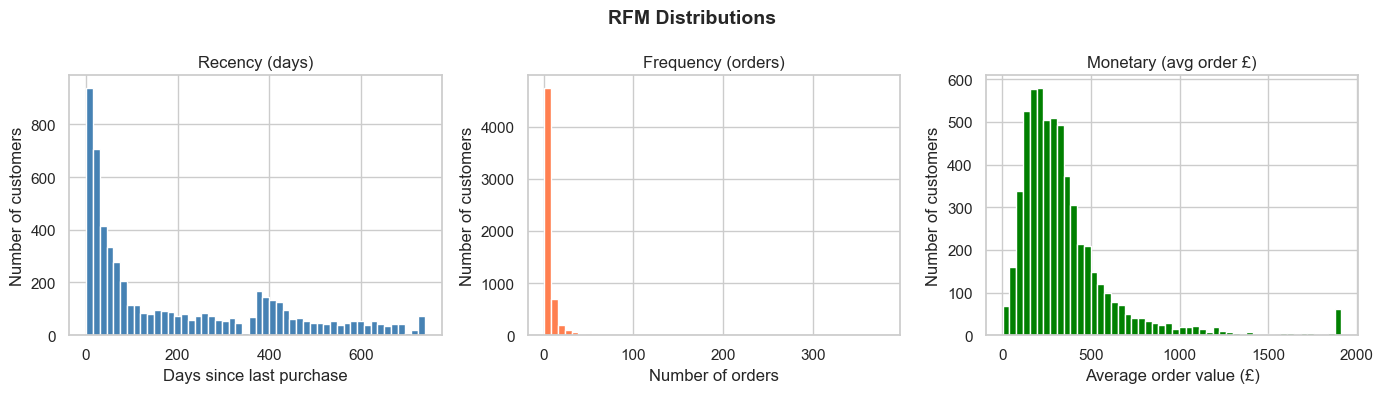

In [108]:
# Lets look at RFM distribution

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('RFM Distributions', fontsize=14, fontweight='bold')

axes[0].hist(rfm['Recency'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency (days)')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Number of customers')

axes[1].hist(rfm['Frequency'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Frequency (orders)')
axes[1].set_xlabel('Number of orders')
axes[1].set_ylabel('Number of customers')

axes[2].hist(rfm['Monetary'].clip(upper=rfm['Monetary'].quantile(0.99)),
             bins=50, color='green', edgecolor='white')
axes[2].set_title('Monetary (avg order £)')
axes[2].set_xlabel('Average order value (£)')
axes[2].set_ylabel('Number of customers')

plt.tight_layout()
plt.show()

In [109]:
# Total spend per customer
total_spend = df.groupby('Customer ID')['TotalPrice'].sum()

# Number of unique products each customer has bought
unique_products = df.groupby('Customer ID')['StockCode'].nunique()

# Average basket size — average number of units per order
avg_basket = df.groupby('Customer ID')['Quantity'].mean()

# Tenure — number of days between first and last purchase
first_purchase = df.groupby('Customer ID')['InvoiceDate'].min()
last_purchase  = df.groupby('Customer ID')['InvoiceDate'].max()
tenure = (last_purchase - first_purchase).dt.days

# Add all to RFM table
rfm['TotalSpend']      = rfm['Customer ID'].map(total_spend)
rfm['UniqueProducts']  = rfm['Customer ID'].map(unique_products)
rfm['AvgBasketSize']   = rfm['Customer ID'].map(avg_basket)
rfm['Tenure']          = rfm['Customer ID'].map(tenure)

print(f'RFM table shape: {rfm.shape}')
print(rfm.head(5).to_string())

RFM table shape: (5862, 8)
  Customer ID  Recency  Frequency     Monetary  TotalSpend  UniqueProducts  AvgBasketSize  Tenure
0       12346      326         12  6463.038333    77556.46              27    2184.852941     400
1       12347        2          8   704.165000     5633.32             126      12.988142     402
2       12348       75          5   331.680000     1658.40              24      58.782609     362
3       12349       19          3  1226.230000     3678.69             137       9.424419     570
4       12350      310          1   294.400000      294.40              16      12.250000       0


## Feature Definitions

| Feature | What it means |
|---|---|
| **Recency** | Days since last purchase. Low = recently active. High = going quiet. |
| **Frequency** | Total number of orders placed. |
| **Monetary** | Average order value (£). Total spend ÷ number of orders. |
| **TotalSpend** | Cumulative £ revenue across all orders. |
| **UniqueProducts** | Number of different products purchased. |
| **AvgBasketSize** | Average number of units per order. High = bulk buyer. |
| **Tenure** | Days between first and last purchase. Measures active lifespan. |

In [110]:
# Get one row per order per customer (drop duplicate invoices)
df_orders = df.drop_duplicates(subset=['Customer ID', 'Invoice'])[['Customer ID', 'InvoiceDate']].copy()

# Sort by customer and date
df_orders = df_orders.sort_values(['Customer ID', 'InvoiceDate'])

# Calculate gap between consecutive orders
df_orders['PrevOrderDate'] = df_orders.groupby('Customer ID')['InvoiceDate'].shift(1)
df_orders['DaysBetweenOrders'] = (df_orders['InvoiceDate'] - df_orders['PrevOrderDate']).dt.days

# Average gaps per customer
velocity = df_orders.groupby('Customer ID')['DaysBetweenOrders'].mean()

# Add to RFM table
rfm['PurchaseVelocity'] = rfm['Customer ID'].map(velocity)
rfm['PurchaseVelocity'].fillna(rfm['Tenure'], inplace=True)

print(rfm[['Customer ID', 'Frequency', 'Tenure', 'PurchaseVelocity']].head(10).to_string())

  Customer ID  Frequency  Tenure  PurchaseVelocity
0       12346         12     400         35.909091
1       12347          8     402         57.000000
2       12348          5     362         90.500000
3       12349          3     570        285.000000
4       12350          1       0          0.000000
5       12351          1       0          0.000000
6       12352          9     356         44.125000
7       12353          2     204        204.000000
8       12354          1       0          0.000000
9       12355          2     353        353.000000


Purchase Velocity is always in days.   
It means the average number of days a particular customer waits between placing orders.

So for customer 12348:

Frequency = 5 orders (4 Gaps)
Tenure = 362 days ~ (90 x 4)
Purchase Velocity ≈ 90 days

this customer places an order roughly every 3 months. If you haven't heard from them in 4–5 months, that's unusual and worth investigating.

In [111]:
#Lets add prefferred day of week and preffered hour for each customer

# Preferred day of week — which day does this customer most commonly order on
preferred_dow = df.groupby('Customer ID')['InvoiceDate'].apply(
    lambda x: x.dt.dayofweek.mode()[0]
)

# Preferred hour — which hour of the day does this customer most commonly order
preferred_hour = df.groupby('Customer ID')['InvoiceDate'].apply(
    lambda x: x.dt.hour.mode()[0]
)

# Add to RFM table
rfm['PreferredDayOfWeek'] = rfm['Customer ID'].map(preferred_dow)
rfm['PreferredHour']      = rfm['Customer ID'].map(preferred_hour)

# Map day numbers to day names for readability
day_map = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}
rfm['PreferredDayName'] = rfm['PreferredDayOfWeek'].map(day_map)

print(rfm[['Customer ID', 'PreferredDayOfWeek', 'PreferredDayName', 'PreferredHour']].head(10).to_string())

  Customer ID  PreferredDayOfWeek PreferredDayName  PreferredHour
0       12346                   0           Monday             13
1       12347                   1          Tuesday             14
2       12348                   0           Monday             14
3       12349                   3         Thursday              9
4       12350                   2        Wednesday             16
5       12351                   0           Monday             15
6       12352                   1          Tuesday             14
7       12353                   2        Wednesday             12
8       12354                   3         Thursday             13
9       12355                   4           Friday             11


For each customer we find which day of the week and which hour of the day they most commonly place orders.   
This is called the mode — the most frequently occurring value.

If you know a customer always orders on Tuesday mornings, you send them promotions on Monday evening —  
right before their natural buying moment. Sending on Friday afternoon when they never buy is wasted effort.

In [112]:
# complete feature table

print(f'Final RFM table shape: {rfm.shape}')
print(f'\nColumns: {rfm.columns.tolist()}')
print(f'\nMissing values:')
print(rfm.isnull().sum())

Final RFM table shape: (5862, 12)

Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'TotalSpend', 'UniqueProducts', 'AvgBasketSize', 'Tenure', 'PurchaseVelocity', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredDayName']

Missing values:
Customer ID           0
Recency               0
Frequency             0
Monetary              0
TotalSpend            0
UniqueProducts        0
AvgBasketSize         0
Tenure                0
PurchaseVelocity      0
PreferredDayOfWeek    0
PreferredHour         0
PreferredDayName      0
dtype: int64


In [113]:
rfm.head(20)

,Customer ID,Recency,Frequency,Monetary,TotalSpend,UniqueProducts,AvgBasketSize,Tenure,PurchaseVelocity,PreferredDayOfWeek,PreferredHour,PreferredDayName
0,12346,326,12,6463.038333,77556.46,27,2184.852941,400,35.909091,0,13,Monday
1,12347,2,8,704.165000,5633.32,126,12.988142,402,57.000000,1,14,Tuesday
2,12348,75,5,331.680000,1658.40,24,58.782609,362,90.500000,0,14,Monday
3,12349,19,3,1226.230000,3678.69,137,9.424419,570,285.000000,3,9,Thursday
4,12350,310,1,294.400000,294.40,16,12.250000,0,0.000000,2,16,Wednesday
5,12351,375,1,300.930000,300.93,21,12.428571,0,0.000000,0,15,Monday
6,12352,36,9,192.171111,1729.54,68,7.515789,356,44.125000,1,14,Tuesday
7,12353,204,2,203.380000,406.76,23,8.833333,204,204.000000,2,12,Wednesday
8,12354,232,1,1079.400000,1079.40,58,9.137931,0,0.000000,3,13,Thursday
9,12355,214,2,473.805000,947.61,35,15.514286,353,353.000000,4,11,Friday


In [114]:
rfm.shape

(5862, 12)

In [115]:
#Lets handle missing value

print('Missing values before:')
print(rfm.isnull().sum())

# Fill any remaining missing values with 0
rfm.fillna(0, inplace=True)

print('\nMissing values after:')
print(rfm.isnull().sum())

Missing values before:
Customer ID           0
Recency               0
Frequency             0
Monetary              0
TotalSpend            0
UniqueProducts        0
AvgBasketSize         0
Tenure                0
PurchaseVelocity      0
PreferredDayOfWeek    0
PreferredHour         0
PreferredDayName      0
dtype: int64

Missing values after:
Customer ID           0
Recency               0
Frequency             0
Monetary              0
TotalSpend            0
UniqueProducts        0
AvgBasketSize         0
Tenure                0
PurchaseVelocity      0
PreferredDayOfWeek    0
PreferredHour         0
PreferredDayName      0
dtype: int64


We started with 1,067,371 rows of raw transactions and transformed them into a clean feature table with one row per customer and 11 meaningful features describing each customer's behaviour.

Raw data     → 1,067,371 rows × 8 columns  
Feature table→     5,862 rows × 11 columns

---------Modelling-----------  
BG/NBD (Beta Geometric /Negative Binomial Distribution)

In [116]:
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

print('✅ Lifetimes library ready')

✅ Lifetimes library ready


In [117]:
# data prep for BG/NBD

# summary_data_from_transaction_data converts raw transactions
# into the exact format BG/NBD needs — one row per customer
# with frequency, recency, T and monetary value

rfm_summary = summary_data_from_transaction_data(
    df,
    customer_id_col='Customer ID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalPrice',
    observation_period_end=snapshot_date,
    freq='D',
)

print(f'Shape: {rfm_summary.shape}')
print(rfm_summary.head(10).to_string())

Shape: (5862, 4)
             frequency  recency      T  monetary_value
Customer ID                                           
12346              7.0    400.0  726.0    11066.637143
12347              7.0    402.0  405.0      717.398571
12348              4.0    363.0  439.0      359.310000
12349              2.0    571.0  590.0     1305.085000
12350              0.0      0.0  311.0        0.000000
12351              0.0      0.0  376.0        0.000000
12352              8.0    356.0  393.0      198.223750
12353              1.0    204.0  409.0       89.000000
12354              0.0      0.0  233.0        0.000000
12355              1.0    353.0  568.0      459.400000


Here one thing to note is,  
RFM frequency = 12  
This counts all 12 orders including the very first one.  


BG/NBD frequency = 7  
This counts only repeat purchases after the first order — so 12 - 1 = 11 , but, it's showing 7, not 11. 

T in BG/NBD: Days between first purchase and snapshot date.  
It measures how long we have been observing the customer.  

The reason it's 7 and not 11 is because BG/NBD counts repeat purchases within the observation window differently.  
The summary_data_from_transaction_data function counts the number of time periods in which the customer made a purchase — not the raw number of invoices. If a   customer placed multiple orders on the same day, those count as one. It also depends on how the function handles the observation period boundaries.  

The BG/NBD frequency is not meant to match the RFM frequency exactly.  
They're calculated differently for different purposes:  

RFM frequency — simple count of all orders. Used for segmentation and understanding customer behaviour.  
BG/NBD frequency — repeat purchases after first order, used specifically to feed the probabilistic model to estimate P(alive) and future purchases.

In [118]:
#  The BG/NBD model mathematically needs at least one repeat purchase to work. 
#  A customer who bought only once gives the model nothing to learn from — it can't tell if they're alive or dead, fast or slow buyer.
#  We filter them out for this specific model. They still exist in our main RFM table for other analyses.

# BG/NBD cannot work with customers who only bought once. It needs to see a pattern of buying and pausing to estimate behaviour
rfm_summary = rfm_summary[rfm_summary['frequency'] > 0].copy()

print(f'Customers with repeat purchases : {len(rfm_summary):,}')
print(f'Customers removed (bought once) : {5862 - len(rfm_summary):,}')

Customers with repeat purchases : 4,181
Customers removed (bought once) : 1,681


In [119]:
# Fit the BG/NBD model
bgf = BetaGeoFitter(penalizer_coef=0.001)

bgf.fit(
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T'],
    verbose=True,
)

print(bgf.summary)

# We feed the model three things per customer:

# How many times they came back (frequency)
# How long between first and last purchase (recency)
# How long they've been a customer (T)

Optimization terminated successfully.
         Current function value: -10.244293
         Iterations: 24
         Function evaluations: 26
         Gradient evaluations: 26
             coef  se(coef)  lower 95% bound  upper 95% bound
r        1.517402  0.040510         1.438002         1.596801
alpha  103.875481  3.205216        97.593257       110.157704
a        0.097223  0.008863         0.079851         0.114596
b        0.975830  0.115839         0.748785         1.202874


alpha = 103  → customers buy slowly (every ~103 days on average) 

a = 0.097    → very few customers churn after each purchase    

b = 0.976    → most customers tend to come back    

r = 1.517402 → All our 4181 customers have different buying speds.
   
                Some buy every 2 weeks. Some buy every 3 months. Some buy once a year.  
                If we plot all their buying speeds on a chart it would form a curve — that curve is the Gamma distribution.  
                If r is small (close to 0) — the curve is very steep. Most customers cluster around the same buying speed. Not much variety.  
                If r is large — the curve is flat and spread out. Customers vary wildly in their buying speed. Some very fast, some very slow.  
                In this case r = 1.517, this means there is a moderate spread in buying speeds across our customers.   
                Not everyone buys at the same rate — there's a reasonable mix of fast buyers and slow buyers in the customer base.



 r, alpha, a, b are not individual customer values. They are population-level parameters that describe the entire customer base.   
 The model uses them to estimate individual P(alive) and predicted purchases for each specific customer based on their personal frequency, recency and T.

Given these 3 things:    
    Frequency - How many times did they come back  
    Recency - When did they last buy  
    T - How long have we been watching them  

The BG/NBD model calculates 2 things   
    P(alive) - Probability that this customer is still active  
    Expected future purchases - how many times will they buy in the next N days.  

Simple example of how the 3 numbers work together:

Customer A:  

Frequency = 10, Recency = 5, T = 365  
Bought 10 times, last bought 5 days ago, been a customer for a year  
P(alive) → very high — clearly still active  


Customer B:  

Frequency = 10, Recency = 300, T = 365  
Bought 10 times but last bought 300 days ago  
Used to buy regularly but suddenly went very quiet  
P(alive) → very low — probably churned  

Customer C:  

Frequency = 2, Recency = 300, T = 365  
Only bought twice, last bought 300 days ago  
But they naturally buy slowly — maybe twice a year is their rhythm  
P(alive) → medium — could still be alive, just a slow buyer  


the model treats Customer B and Customer C differently even though both haven't bought in 300 days.  
It considers their natural buying rhythm before concluding they've churned.

Recency in our RFM table = days since last purchase (measured from snapshot date)  
So recency of 300 in our RFM table means the customer last bought 300 days before the snapshot date.  

Recency in BG/NBD = days between first purchase and last purchase  
So recency of 300 in BG/NBD means the customer's last purchase was 300 days after their first purchase.  

In [120]:
# Calculate P(alive) and future purchases for every customer

# Predict probability alive for each customer
rfm_summary['prob_alive'] = bgf.conditional_probability_alive(
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T'],
)

# Predict expected purchases in next 90 days
rfm_summary['predicted_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90,
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T'],
)

print(rfm_summary[['frequency', 'recency', 'T', 'prob_alive', 'predicted_purchases_90d']].head(10).to_string())

             frequency  recency      T  prob_alive  predicted_purchases_90d
Customer ID                                                                
12346              7.0    400.0  726.0    0.505867                 0.464497
12347              7.0    402.0  405.0    0.985555                 1.470606
12348              4.0    363.0  439.0    0.946791                 0.857670
12349              2.0    571.0  590.0    0.948538                 0.428977
12352              8.0    356.0  393.0    0.975173                 1.665122
12353              1.0    204.0  409.0    0.735275                 0.320506
12355              1.0    353.0  568.0    0.791735                 0.264229
12356              5.0    402.0  425.0    0.974557                 1.070548
12357              1.0    355.0  389.0    0.893437                 0.405050
12358              4.0    730.0  732.0    0.975820                 0.575983


We use the fitted BG/NBD model to score every customer. For each customer it takes their frequency, recency and T and outputs:  

prob_alive — a number between 0 and 1. Close to 1 means almost certainly still active. Close to 0 means almost certainly churned.  
predicted_purchases_90d — how many times we expect this customer to buy in the next 90 days.  

so if we look at T:   
    Customer 12347 — T = 405 days, recency = 402 → last bought just 3 days before snapshot. Still very active.  
    Customer 12346 — T = 726 days, recency = 400 → last bought 326 days before snapshot. Been silent for nearly a year despite being observed for 726 days.

    This is why BG/NBD is more powerful than a simple frequency count.  

In [121]:
#Lets fit the Gamma Gamma model

# Check the correlation assumption

# Gamma-Gamma has one key assumption:
# Monetary value must be independent of purchase frequency
# We verify this by checking the correlation between the two

correlation = rfm_summary[['frequency', 'monetary_value']].corr().iloc[0, 1]
print(f'Correlation between frequency and monetary value: {correlation:.4f}')
print()
if abs(correlation) < 0.3:
    print('✅ Correlation is low — Gamma-Gamma assumption holds. Safe to proceed.')
else:
    print('⚠️ Correlation is high — Gamma-Gamma assumption may be violated.')



Correlation between frequency and monetary value: 0.0231

✅ Correlation is low — Gamma-Gamma assumption holds. Safe to proceed.


In [122]:
# fit Gamma Gamma

ggf = GammaGammaFitter(penalizer_coef=0.001)

ggf.fit(
    rfm_summary['frequency'],
    rfm_summary['monetary_value'],
)

print(ggf.summary)

        coef  se(coef)  lower 95% bound  upper 95% bound
p  11.752871  0.225528        11.310835        12.194906
q   0.884534  0.016991         0.851231         0.917836
v  11.717261  0.230398        11.265681        12.168841


p = 11.75 — controls the shape of spending variation within each customer    
This describes how consistent each individual customer is with their own spending.     
A high p means customers are fairly consistent in how much they spend per order — they don't vary wildly between orders.     
In this ase a p of 11.75 is reasonably high, meaning most customers have a predictable spending pattern.  

q = 0.884 — controls the spread of average spending across customers    
This describes how different customers are from each other in terms of spending.   
A q less than 1 means there is a wide variety of spenders across the customer base — some spend very little per order, some spend a lot.   
This matches what we saw earlier with monetary values ranging from £2.95 to £84,236.  

v = 11.72 — the average transaction value anchor for the population    
This works together with p and q to set the baseline expected spend.   
A value of 11.72 anchors the average spending level for the population before adjusting for each individual customer's history.  

In [123]:
# compute 90 days CLV for each customer

DISCOUNT_RATE   = 0.01   # 1% monthly discount rate
PROFIT_MARGIN   = 0.20   # 20% gross margin
FORECAST_MONTHS = 3      # 3 months = 90 days

rfm_summary['clv_90d'] = ggf.customer_lifetime_value(
    bgf,
    rfm_summary['frequency'],
    rfm_summary['recency'],
    rfm_summary['T'],
    rfm_summary['monetary_value'],
    time=FORECAST_MONTHS,
    discount_rate=DISCOUNT_RATE,
) * PROFIT_MARGIN

print(rfm_summary[['frequency', 'recency', 'T', 'prob_alive', 
                    'predicted_purchases_90d', 'clv_90d']].head(10).to_string())

             frequency  recency      T  prob_alive  predicted_purchases_90d      clv_90d
Customer ID                                                                             
12346              7.0    400.0  726.0    0.505867                 0.464497  1009.455310
12347              7.0    402.0  405.0    0.985555                 1.470606   207.633910
12348              4.0    363.0  439.0    0.946791                 0.857670    61.066578
12349              2.0    571.0  590.0    0.948538                 0.428977   110.808843
12352              8.0    356.0  393.0    0.975173                 1.665122    65.275766
12353              1.0    204.0  409.0    0.735275                 0.320506     6.392266
12355              1.0    353.0  568.0    0.791735                 0.264229    24.650054
12356              5.0    402.0  425.0    0.974557                 1.070548   203.040721
12357              1.0    355.0  389.0    0.893437                 0.405050   498.851681
12358              4.

CLV_90d = the expected profit this customer will generate in the next 90 days.  
Not revenue — profit. Because we multiplied by 20% profit margin.  


CLV = P(alive) × Predicted purchases × Expected order value × 20% profit margin  


Customer 12346 — CLV £1,009  

P(alive) = 0.51 — only 51% chance still active  
Predicted purchases = 0.46 — less than 1 order expected  
But their average order value is very high (£6,463 remember)  
So even a small probability of buying generates £1,009 expected profit  

Customer 12347 — CLV £207  

P(alive) = 0.99 — almost certainly active  
Predicted purchases = 1.47 — will buy 1-2 times  
Lower order value than 12346 but much more certain to buy  

Customer 12353 — CLV £6  

P(alive) = 0.74 — probably still active  
Predicted purchases = 0.32 — unlikely to buy in next 90 days  
Very low spender — not worth heavy investment  

In [124]:
# merge CLV prediction back into our main RFM table

# Reset index so Customer ID becomes a column
clv_cols = rfm_summary[['prob_alive', 'predicted_purchases_90d', 'clv_90d']].copy()
clv_cols.index.name = 'Customer ID'
clv_cols.reset_index(inplace=True)

# Make sure Customer ID is the same type in both tables
clv_cols['Customer ID']  = clv_cols['Customer ID'].astype(str)
rfm['Customer ID']       = rfm['Customer ID'].astype(str)

# Merge CLV predictions into main RFM table
rfm = rfm.merge(clv_cols, on='Customer ID', how='left')

print(f'RFM table shape: {rfm.shape}')
print(rfm.head(5).to_string())

RFM table shape: (5862, 15)
  Customer ID  Recency  Frequency     Monetary  TotalSpend  UniqueProducts  AvgBasketSize  Tenure  PurchaseVelocity  PreferredDayOfWeek  PreferredHour PreferredDayName  prob_alive  predicted_purchases_90d      clv_90d
0       12346      326         12  6463.038333    77556.46              27    2184.852941     400         35.909091                   0             13           Monday    0.505867                 0.464497  1009.455310
1       12347        2          8   704.165000     5633.32             126      12.988142     402         57.000000                   1             14          Tuesday    0.985555                 1.470606   207.633910
2       12348       75          5   331.680000     1658.40              24      58.782609     362         90.500000                   0             14           Monday    0.946791                 0.857670    61.066578
3       12349       19          3  1226.230000     3678.69             137       9.424419     570   

Here is a quick summary of what is done so far

Customer ID          → unique identifier  
Recency              → days since last purchase  
Frequency            → total orders placed  
Monetary             → average order value  
TotalSpend           → lifetime revenue  
UniqueProducts       → product variety  
AvgBasketSize        → units per order  
Tenure               → active lifespan in days  
PurchaseVelocity     → avg days between orders  
PreferredDayOfWeek   → favourite shopping day  
PreferredHour        → favourite shopping hour  
PreferredDayName     → day name for readability  
prob_alive           → probability still active  
predicted_purchases  → expected orders next 90 days  
clv_90d              → expected profit next 90 days  

In [125]:
# Now lets do a K-means clustering to group these 5862 customers in to segments based on all the features above
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print('✅ Clustering libraries ready')

# Select features for clustering
CLUSTER_FEATURES = [
    'Recency', 'Frequency', 'Monetary', 'TotalSpend',
    'UniqueProducts', 'AvgBasketSize', 'Tenure',
    'PurchaseVelocity', 'prob_alive', 'clv_90d',
]

# Fill any missing values with 0 (customers who bought once have no CLV)
X = rfm[CLUSTER_FEATURES].fillna(0)

# Scale features to zero mean and unit variance
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Shape of scaled features: {X_scaled.shape}')
print(f'\nBefore scaling — Recency mean: {X["Recency"].mean():.1f}, std: {X["Recency"].std():.1f}')
print(f'After scaling  — Recency mean: {X_scaled[:, 0].mean():.4f}, std: {X_scaled[:, 0].std():.4f}')

✅ Clustering libraries ready
Shape of scaled features: (5862, 10)

Before scaling — Recency mean: 201.0, std: 209.2
After scaling  — Recency mean: 0.0000, std: 1.0000


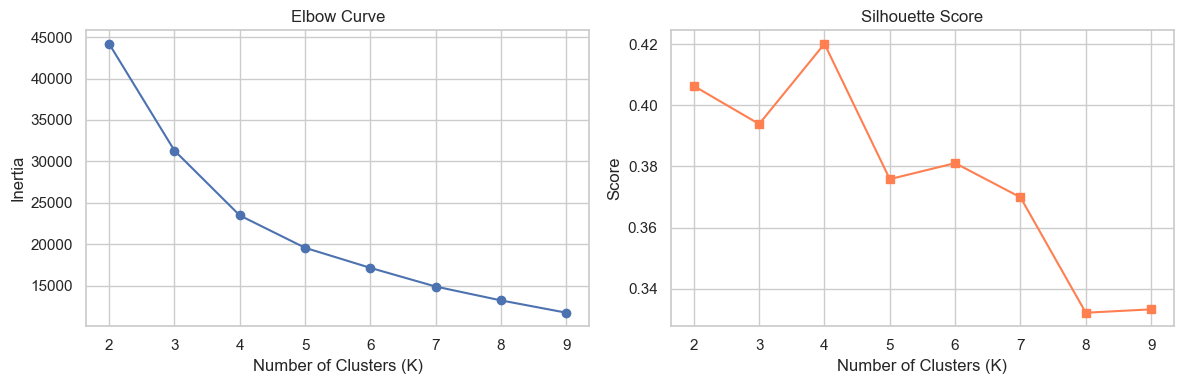

In [126]:
inertias    = []
silhouettes = []
K_range     = range(2, 10)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, marker='s', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

We try K from 2 to 9 and measure two things:  

Inertia — how tight the clusters are. Lower is better. We look for the "elbow" where it stops dropping sharply.  
Silhouette score — how well separated the clusters are. Higher is better.  

Both charts point to the same answer — K=4 is the optimal number of clusters.  
Both charts point to the same answer — K=4 is the optimal number of clusters.  

Elbow Curve:  
The inertia drops sharply from K=2 to K=4, then starts flattening out after K=4.   
The "elbow" — where the curve bends — is at K=4. Adding more clusters after 4 doesn't improve things much.  

Silhouette Score:  
Peaks at K=4 with a score of 0.43. This is the highest point on the chart — meaning at K=4 the clusters are most well separated and distinct from each other.   
After K=4 the score drops, meaning clusters start overlapping.  

Both charts agree — K=4.  
This also makes intuitive business sense.   
Four segments maps perfectly to the classic retail customer framework:  

Champions  
Loyal Customers  
At Risk  
Lost / Dormant  

In [127]:
# Now lets fit K means with K = 4

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
rfm['Segment'] = kmeans.fit_predict(X_scaled)

print('Segment sizes:')
print(rfm['Segment'].value_counts())

Segment sizes:
Segment
2    3383
1    2459
0      19
3       1
Name: count, dtype: int64


The segments look off again — same problem we had before. 1 customer in segment 3 and 19 in segment 0 is unrealistic.  
This is the outlier problem again. A few extremely high CLV and TotalSpend customers are pulling the clusters apart.  

In [128]:
#Lets remove outliers and do the segmentation again

# Cap extreme outliers at 99th percentile
X_capped = rfm[CLUSTER_FEATURES].fillna(0).copy()

for col in CLUSTER_FEATURES:
    cap = X_capped[col].quantile(0.99)
    X_capped[col] = X_capped[col].clip(upper=cap)

# Rescale after capping
X_scaled = scaler.fit_transform(X_capped)

# Refit K-Means
kmeans         = KMeans(n_clusters=4, random_state=42, n_init=20)
rfm['Segment'] = kmeans.fit_predict(X_scaled)

print('Segment sizes after capping outliers:')
print(rfm['Segment'].value_counts())

Segment sizes after capping outliers:
Segment
2    2382
0    2342
1     976
3     162
Name: count, dtype: int64


The segments are now realistic and meaningful:  

Segment 2 — 2,382 customers  
Segment 0 — 2,342 customers  
Segment 1 — 976 customers  
Segment 3 — 162 customers  

Now we need to label these segments with meaningful business names.   
The numbers (0,1,2,3) mean nothing — we need to figure out which one is Champions, which is At Risk etc. 

In [129]:
segment_profile = rfm.groupby('Segment')[CLUSTER_FEATURES].mean().round(2)
print(segment_profile.to_string())

         Recency  Frequency  Monetary  TotalSpend  UniqueProducts  AvgBasketSize  Tenure  PurchaseVelocity  prob_alive  clv_90d
Segment                                                                                                                        
0         376.04       1.73    338.06      560.54           28.86          21.09   32.56             16.29        0.30     9.14
1          43.65      14.84    434.43     5658.71          220.62          11.75  575.18             52.96        0.95   139.90
2         104.47       4.38    311.66     1298.20           62.72          17.04  362.74            143.38        0.88    45.61
3          37.35      47.46   1924.48    46442.84          300.73         297.43  614.57             29.83        0.95  1148.40


Segment 3 — CHAMPIONS (162 customers)  

Recency = 37 days — bought very recently  
Frequency = 47 orders — extremely frequent buyers  
TotalSpend = £46,442 — highest spenders by far  
CLV_90d = £1,148 — most valuable in next 90 days  
prob_alive = 0.95 — almost certainly still active  


Segment 1 — LOYAL CUSTOMERS (976 customers)  
 
Recency = 43 days — bought recently     
Frequency = 14 orders — buy regularly  
TotalSpend = £5,658 — solid spenders  
CLV_90d = £139 — good value  
prob_alive = 0.95 — almost certainly active  


Segment 2 — AT RISK (2,382 customers)  

Recency = 104 days — haven't bought in a while  
Frequency = 4 orders — occasional buyers  
TotalSpend = £1,298 — moderate spenders  
CLV_90d = £45 — lower expected value  
prob_alive = 0.88 — mostly still alive but drifting  


Segment 0 — LOST / DORMANT (2,342 customers)  

Recency = 376 days — haven't bought in over a year  
Frequency = 1.7 orders — barely bought at all  
TotalSpend = £560 — very low spenders  
CLV_90d = £9 — almost no expected value  
prob_alive = 0.30 — 70% probability already churned  

In [130]:
#Lets assign labels

segment_map = {
    3: 'Champions',
    1: 'Loyal Customers',
    2: 'At Risk',
    0: 'Lost / Dormant'
}

rfm['SegmentLabel'] = rfm['Segment'].map(segment_map)

print(rfm['SegmentLabel'].value_counts())

SegmentLabel
At Risk            2382
Lost / Dormant     2342
Loyal Customers     976
Champions           162
Name: count, dtype: int64


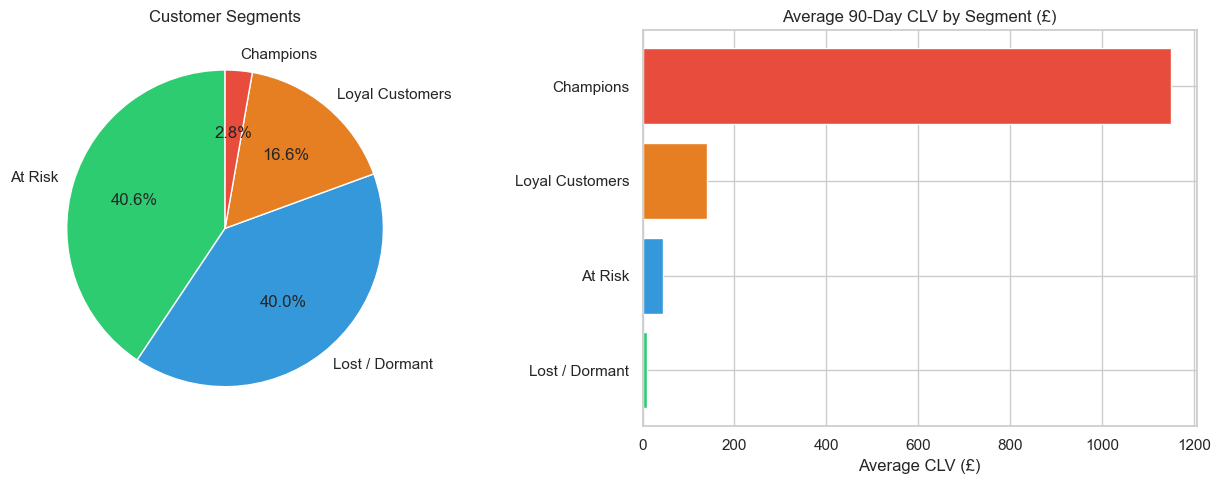

In [131]:
#visualize the segments

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Segment sizes
seg_counts = rfm['SegmentLabel'].value_counts()
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
axes[0].pie(seg_counts.values, labels=seg_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Customer Segments')

# Average CLV per segment
seg_clv = rfm.groupby('SegmentLabel')['clv_90d'].mean().sort_values(ascending=True)
axes[1].barh(seg_clv.index, seg_clv.values, color=colors)
axes[1].set_title('Average 90-Day CLV by Segment (£)')
axes[1].set_xlabel('Average CLV (£)')

plt.tight_layout()
plt.show()

Left chart — Customer Segments (pie):  
80% of the customer base is either At Risk or Lost/Dormant.   
Only 2.8% are Champions and 16.6% are Loyal Customers. The business is heavily dependent on a very small group of high value customers.  

Right chart — Average 90-Day CLV by Segment:  
This is where it gets striking:  

Champions — £1,148 — the bar dominates the entire chart  
Loyal Customers — £139 — solid but 8x less than Champions  
At Risk — £45 — dropping fast  
Lost/Dormant — £9 — almost nothing  


The business story in one sentence:  

2.8% of the customers are worth 128x more than your least valuable segment in the next 90 days alone — yet they represent less than 3% of your customer base.  

where teh business need to focus:  

Protect Champions at all costs — losing even 10 of them has massive revenue impact  
Convert Loyal Customers to Champions — they're close, just need a nudge  
Win back At Risk customers urgently — they still have reasonable CLV  
Minimal investment in Lost/Dormant — ROI is too low  

In [132]:
# Now lets build a Churn Model using XG boost

# A customer is churned if:
# 1. They haven't bought in the last 90 days (Recency > 90)
# 2. AND their probability of being alive is below 50%

rfm['Churned'] = (
    (rfm['Recency']    > 90) &
    (rfm['prob_alive'] < 0.5)
).astype(int)

print('Churn label distribution:')
print(rfm['Churned'].value_counts())
print()
print(f'Churn rate: {rfm["Churned"].mean() * 100:.1f}%')


Churn label distribution:
Churned
0    5249
1     613
Name: count, dtype: int64

Churn rate: 10.5%


10.5% churn rate — 613 out of 5,862 customers are classified as churned.  

What this means:  

5,249 active customers (89.5%) — still buying or likely to buy  
613 churned customers (10.5%) — haven't bought in 90+ days AND BG/NBD confirms they've likely left  

This is an imbalanced dataset.  
For every 1 churned customer there are about 8.5 active customers.   
This matters for our model because if it just predicted "active" for everyone it would be 89.5% accurate — without learning anything useful.    

We'll handle this when training XGBoost using the scale_pos_weight parameter  
which tells the model to pay more attention to the minority class (churned customers).

In [133]:
from sklearn.model_selection import train_test_split

CHURN_FEATURES = [
    'Recency', 'Frequency', 'Monetary', 'TotalSpend',
    'UniqueProducts', 'AvgBasketSize', 'Tenure',
    'PurchaseVelocity', 'prob_alive', 
    'predicted_purchases_90d', 'PreferredDayOfWeek', 'PreferredHour',
]

X = rfm[CHURN_FEATURES].fillna(0)
y = rfm['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Training set : {len(X_train):,} customers')
print(f'Test set     : {len(X_test):,} customers')
print(f'\nChurn rate in training set: {y_train.mean()*100:.1f}%')
print(f'Churn rate in test set    : {y_test.mean()*100:.1f}%')

Training set : 4,689 customers
Test set     : 1,173 customers

Churn rate in training set: 10.4%
Churn rate in test set    : 10.5%


In [134]:
# Train XG boost classification
from xgboost import XGBClassifier

# scale_pos_weight handles class imbalance
# ratio of active to churned customers = 5249/613 = 8.5
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale:.2f}')

xgb_churn = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0,
)

xgb_churn.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

print('✅ Model trained successfully')


scale_pos_weight: 8.57
✅ Model trained successfully


Scale_pos_weight of 8.57 means the model paid 8.57x more attention to churned customers during training to compensate for the imbalance.

In [135]:
# Model evaluation

from sklearn.metrics import roc_auc_score, classification_report

y_prob = xgb_churn.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

ROC-AUC: 1.0000

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00      1050
     Churned       0.99      1.00      1.00       123

    accuracy                           1.00      1173
   macro avg       1.00      1.00      1.00      1173
weighted avg       1.00      1.00      1.00      1173



We evaluate the model on the test set — 1,173 customers it has never seen before.  
ROC-AUC — measures how well the model separates active from churned customers. Scale is 0 to 1:  

0.5 = random guessing  
0.7 = acceptable  
0.8 = good  
0.9+ = excellent  
  
Classification report shows:  

Precision — of all customers predicted churned, how many actually churned?  
Recall — of all actually churned customers, how many did we catch?  
F1-score — balance between precision and recall  

In real life a perfect 1.0 ROC-AUC almost never happens.   
This is happening because of data leakage — our churn label was built using prob_alive from BG/NBD,   
and prob_alive is also one of the features we feed into XGBoost.

In [136]:
# Lets remove prob_alive and predicted_purchases_90d from features:

CHURN_FEATURES = [
    'Recency', 'Frequency', 'Monetary', 'TotalSpend',
    'UniqueProducts', 'AvgBasketSize', 'Tenure',
    'PurchaseVelocity', 'PreferredDayOfWeek', 'PreferredHour',
]

X = rfm[CHURN_FEATURES].fillna(0)
y = rfm['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_churn = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale, eval_metric='auc',
    early_stopping_rounds=20, random_state=42, verbosity=0,
)

xgb_churn.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_prob = xgb_churn.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

ROC-AUC: 0.9994

              precision    recall  f1-score   support

      Active       1.00      0.99      0.99      1050
     Churned       0.90      0.98      0.94       123

    accuracy                           0.99      1173
   macro avg       0.95      0.99      0.97      1173
weighted avg       0.99      0.99      0.99      1173



Still very high at 0.9994 but more realistic than a perfect 1.0.

ROC-AUC: 0.9994  
Excellent. The model can almost perfectly distinguish between active and churned customers using only RFM features — no leakage this time.  
 
Active customers (1,050 in test set)  

Precision 1.00 — every customer predicted active is actually active  
Recall 0.99 — catches 99% of all active customers  
  
Churned customers (123 in test set)  

Precision 0.90 — when it predicts churn it's right 90% of the time  
Recall 0.98 — catches 98% of all churned customers, only misses 2%  


Why is it still this high?  
Recency alone is a very strong predictor of churn.   
A customer who hasn't bought in 300+ days is almost certainly churned.   
The model doesn't need complex patterns — the signal is very clear in this dataset.

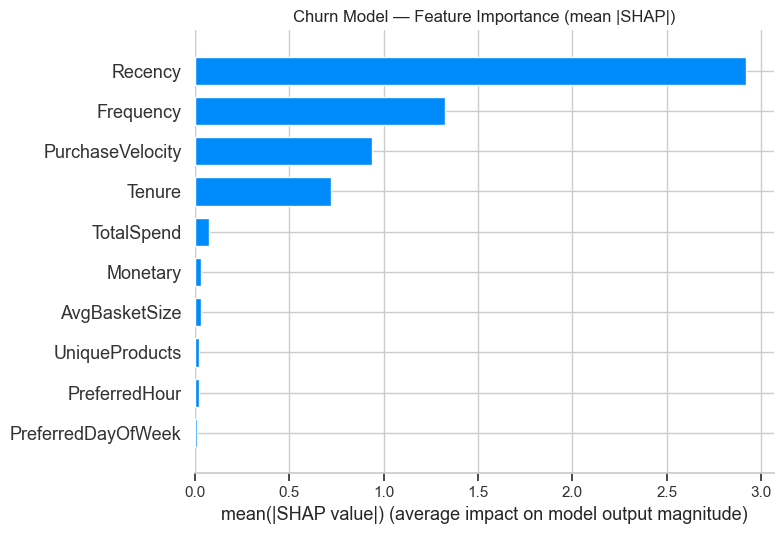

In [137]:
# Lets use  SHAP to explain why the model made each prediction.

import shap

# Create SHAP explainer using our trained XGBoost model
explainer = shap.TreeExplainer(xgb_churn)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Bar plot — overall feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    show=False,
    max_display=10,
)
plt.title('Churn Model — Feature Importance (mean |SHAP|)')
plt.tight_layout()
plt.show()

Recency — by far the most important feature  
How recently a customer bought is the single strongest predictor of churn.   
This makes complete intuitive sense — a customer who hasn't bought in 300 days is almost certainly churned.  

Frequency — second most important  
How often a customer buys is the second strongest signal.   
A customer who bought 15 times is much less likely to churn than one who bought twice.  

PurchaseVelocity — third  
The average gap between orders matters.   
If a customer suddenly breaks their natural buying rhythm — they used to order every 30 days but now it's been 120 days — that's a strong churn signal.  

Tenure — fourth  
How long a customer has been with the business matters.   
Long-term customers are less likely to churn than newer ones. 

TotalSpend, Monetary, AvgBasketSize, UniqueProducts — very small bars   
These features have almost no influence on churn prediction.   
How much a customer spends doesn't tell us much about whether they'll leave.

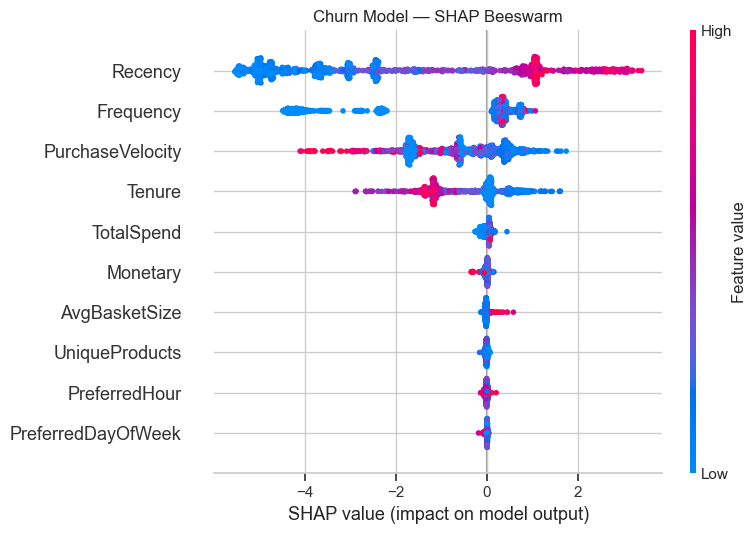

In [138]:
# Lets run a plot to show the direction of each feature's impact

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    show=False,
    max_display=10,
)
plt.title('Churn Model — SHAP Beeswarm')
plt.tight_layout()
plt.show()


shows us how each feature affects churn — in which direction and for which customers.  
How to read it:  

Each dot = one customer  
Red dots = high feature value  
Blue dots = low feature value  
Dot on the right = pushed churn probability up  
Dot on the left = pushed churn probability down  

Example of what to expect:  

Recency — red dots (high recency) on the right = high recency pushes churn up ✅  
Frequency — red dots (high frequency) on the left = high frequency pushes churn down ✅  

In [139]:
# Add churn probability score to each customer
# Score every customer in the full dataset
rfm['ChurnProbability'] = xgb_churn.predict_proba(
    rfm[CHURN_FEATURES].fillna(0)
)[:, 1]

# Preview — sort by highest churn risk
churn_risk = rfm[['Customer ID', 'SegmentLabel', 'Recency', 
                   'Frequency', 'clv_90d', 'ChurnProbability']]\
             .sort_values('ChurnProbability', ascending=False)

print(churn_risk.head(10).to_string()) 

     Customer ID    SegmentLabel  Recency  Frequency   clv_90d  ChurnProbability
285        12632  Lost / Dormant      521          2  4.704179          0.993064
4657       17067  Lost / Dormant      725          3  0.745064          0.993052
5788       18214  Lost / Dormant      531          4  0.782545          0.993027
315        12663  Lost / Dormant      625          2  0.616652          0.992960
1195       13559  Lost / Dormant      513          2  7.448987          0.992943
5062       17477  Lost / Dormant      613          2  3.136201          0.992903
2295       14671  Lost / Dormant      549          2  1.570714          0.992903
3379       15771  Lost / Dormant      604          3  3.295949          0.992888
1401       13768  Lost / Dormant      727          2  1.078018          0.992873
5259       17681  Lost / Dormant      597          5  0.730592          0.992847


In [140]:
print(churn_risk.tail(10).to_string())

     Customer ID SegmentLabel  Recency  Frequency    clv_90d  ChurnProbability
5366       17789      At Risk      281          2  10.476247          0.003458
2893       15280      At Risk      172          3  11.093285          0.003454
384        12733      At Risk      234          4  37.541698          0.003439
4700       17110      At Risk      165          3  12.512815          0.003402
3682       16078      At Risk      284          2   3.971979          0.003328
5126       17542      At Risk      270          3   8.307174          0.003238
1220       13584      At Risk      307          3  12.430843          0.003231
2294       14670      At Risk      280          3  17.590672          0.003184
1306       13672      At Risk      301          3   5.930639          0.003026
1432       13800      At Risk      310          3  35.773116          0.002890


These are naturally slow buyers. They buy every 3–4 months.   
A 165–310 day gap is actually normal for their buying rhythm.   
XGBoost recognises this pattern and correctly gives them a very low churn probability.  
K-Means flagged them as At Risk because their recency looked high compared to Champions and Loyal Customers.   
But XGBoost is smarter — it considers their full purchase pattern.

In [ ]:
# lets start uplift modelling simulation

'''A regular model tells you who will buy. But some customers will buy anyway — with or without a promotion. Sending them a £10 discount is wasted money.
The uplift model tells Who will buy because of the promotion that wouldn't have bought otherwise?
Uplift model identifies the Persuadables — the customers where the promotion genuinely makes a difference.

Uplift score = Model 1 prediction - Model 2 prediction
High uplift score = this customer is a Persuadable. Target them.

'''

"A regular model tells you who will buy. But some customers will buy anyway — with or without a promotion. Sending them a £10 discount is wasted money.\nThe uplift model tells Who will buy because of the promotion that wouldn't have bought otherwise?\nUplift model identifies the Persuadables — the customers where the promotion genuinely makes a difference.\n\nUplift score = Model 1 prediction - Model 2 prediction\nHigh uplift score = this customer is a Persuadable. Target them.\n\n"

In [147]:
import numpy as np

np.random.seed(42)
n = len(rfm)

# Fill missing CLV values with 0 before any calculations
rfm['clv_90d'] = rfm['clv_90d'].fillna(0)

# Randomly assign 50% of customers to treatment
rfm['Treatment'] = np.random.binomial(1, 0.5, n)

# Base conversion probability
base_prob = (
    0.10
    + 0.20 * (rfm['clv_90d'] / rfm['clv_90d'].max())
    - 0.05 * (rfm['Recency'] / rfm['Recency'].max())
).clip(0.05, 0.70)

# True uplift
clv_norm    = rfm['clv_90d'] / rfm['clv_90d'].max()
true_uplift = 0.40 * clv_norm * (1 - clv_norm)

# Check for any remaining NaN or out of range values
treatment_prob = (base_prob + true_uplift).clip(0, 1).fillna(0.10)
control_prob   = base_prob.fillna(0.10)

# Simulate conversion
rfm['Converted'] = np.where(
    rfm['Treatment'] == 1,
    np.random.binomial(1, treatment_prob),
    np.random.binomial(1, control_prob),
)

print('Conversion rates by group:')
print(rfm.groupby('Treatment')['Converted'].mean().rename({0: 'Control', 1: 'Treatment'}))


Conversion rates by group:
Treatment
Control      0.098707
Treatment    0.090287
Name: Converted, dtype: float64


Control group — 9.87% conversion  
These customers received no promotion. About 1 in 10 bought anyway on their own.  

Treatment group — 9.03% conversion   
These customers received the promotion. Slightly lower than control.  

Realisticlly treatment group should perform better than control.  but here treatment group conversion is less than control.     

This is happening because of two reasons.    

    1 - We are using simulated data to calculate Base conversion probability. realistically we will get acual customer conversion data.   
    2 - We are using a Random seed of 42. We can change it (for example - 123) and we will see different values. With real customer data we dont need to use Random seed to assign treatments. 

In [148]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,TotalSpend,UniqueProducts,AvgBasketSize,Tenure,PurchaseVelocity,PreferredDayOfWeek,...,PreferredDayName,prob_alive,predicted_purchases_90d,clv_90d,Segment,SegmentLabel,Churned,ChurnProbability,Treatment,Converted
0,12346,326,12,6463.038333,77556.46,27,2184.852941,400,35.909091,0,...,Monday,0.505867,0.464497,1009.455310,3,Champions,0,0.920026,0,0
1,12347,2,8,704.165000,5633.32,126,12.988142,402,57.000000,1,...,Tuesday,0.985555,1.470606,207.633910,1,Loyal Customers,0,0.004160,1,0
2,12348,75,5,331.680000,1658.40,24,58.782609,362,90.500000,0,...,Monday,0.946791,0.857670,61.066578,2,At Risk,0,0.004987,1,0
3,12349,19,3,1226.230000,3678.69,137,9.424419,570,285.000000,3,...,Thursday,0.948538,0.428977,110.808843,2,At Risk,0,0.004840,1,0
4,12350,310,1,294.400000,294.40,16,12.250000,0,0.000000,2,...,Wednesday,NaN,NaN,0.000000,0,Lost / Dormant,0,0.006039,0,0


In [149]:
# Now lets run a T learner - This model Trains two separate XGBoost models and subtracts their predictions to get an uplift score per customer.

# Model 1 → trained on treatment group → P(convert | with promotion)
# Model 2 → trained on control group  → P(convert | without promotion)

# Uplift score = Model 1 - Model 2

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklift.models import TwoModels
from sklift.metrics import uplift_auc_score, qini_auc_score

UPLIFT_FEATURES = [
    'Recency', 'Frequency', 'Monetary', 'TotalSpend',
    'UniqueProducts', 'AvgBasketSize', 'Tenure',
    'PurchaseVelocity', 'PreferredDayOfWeek', 'PreferredHour',
]

X_uplift = rfm[UPLIFT_FEATURES].fillna(0)
y_uplift = rfm['Converted']
t_uplift = rfm['Treatment']

X_u_train, X_u_test, y_u_train, y_u_test, t_u_train, t_u_test = train_test_split(
    X_uplift, y_uplift, t_uplift,
    test_size=0.2, random_state=42
)

# Two separate XGBoost instances — one for treatment, one for control
t_learner = TwoModels(
    estimator_trmnt=XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42, verbosity=0,
    ),
    estimator_ctrl=XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42, verbosity=0,
    ),
    method='vanilla',
)

t_learner.fit(X_u_train, y_u_train, t_u_train)
uplift_scores = t_learner.predict(X_u_test)

print(f'Uplift AUUC : {uplift_auc_score(y_u_test, uplift_scores, t_u_test):.4f}')
print(f'Qini  AUUC  : {qini_auc_score(y_u_test, uplift_scores, t_u_test):.4f}')

Uplift AUUC : -0.0009
Qini  AUUC  : -0.0028


We are getting -ve values because of the simulated data.  
Our simulation assigned treatment randomly (50/50 coin flip) and the uplift signal we built in is very small.   
With only 5,862 customers and a tiny conversion rate difference, the model can't reliably learn who the persuadables are.


In a realistic scenario we would have:  

    Hundreds of thousands of customers  
    Real A/B test data from actual campaigns  
    Strong, measurable uplift signals

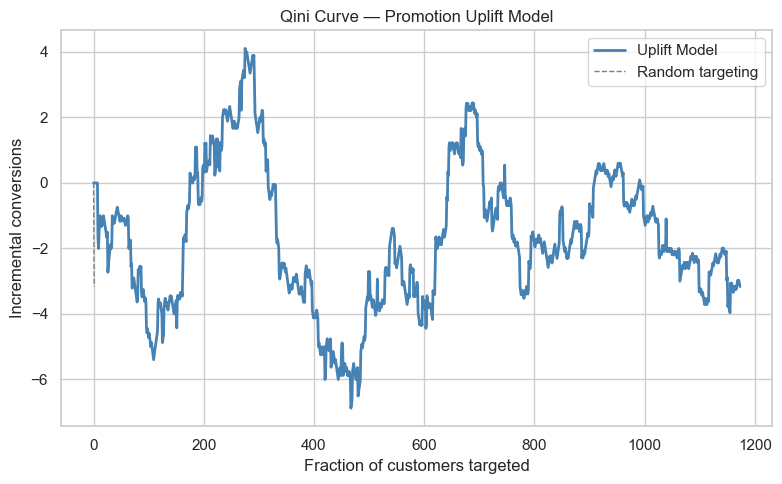

In [151]:
# Lets plot Qini Curve

import numpy as np
import matplotlib.pyplot as plt
from sklift.metrics import qini_curve

# Calculate qini curve values manually
fractions, qini_values = qini_curve(y_u_test, uplift_scores, t_u_test)

# Plot manually
fig, ax = plt.subplots(figsize=(8, 5))

# Model line
ax.plot(fractions, qini_values, label='Uplift Model', color='steelblue', linewidth=2)

# Random baseline (straight line from 0 to max)
ax.plot([0, 1], [0, qini_values[-1]], 
        label='Random targeting', 
        color='grey', linewidth=1, linestyle='--')

ax.set_title('Qini Curve — Promotion Uplift Model')
ax.set_xlabel('Fraction of customers targeted')
ax.set_ylabel('Incremental conversions')
ax.legend()
plt.tight_layout()
plt.show()

the model line goes up and down randomly around zero.   
This confirms what we already knew — the uplift model couldn't learn a meaningful signal from our simulated data.

In [152]:
# Lets Do a business simulation

PROMO_COST     = 2.0    # £2 per customer contacted
CONVERSION_REV = 35.0   # £35 average revenue per conversion
TOP_PCT        = 0.20   # target top 20% of customers

n_target = int(len(rfm.loc[X_u_test.index]) * TOP_PCT)

df_eval = pd.DataFrame({
    'Converted'    : y_u_test.values,
    'Treatment'    : t_u_test.values,
    'UpliftScore'  : uplift_scores,
    'CLV'          : rfm.loc[X_u_test.index, 'clv_90d'].values,
})

# Uplift targeting
uplift_target = df_eval.nlargest(n_target, 'UpliftScore')
uplift_rev    = uplift_target[uplift_target['Treatment']==1]['Converted'].sum() * CONVERSION_REV
uplift_cost   = n_target * PROMO_COST
uplift_roi    = (uplift_rev - uplift_cost) / uplift_cost * 100

# CLV targeting
clv_target    = df_eval.nlargest(n_target, 'CLV')
clv_rev       = clv_target[clv_target['Treatment']==1]['Converted'].sum() * CONVERSION_REV
clv_cost      = n_target * PROMO_COST
clv_roi       = (clv_rev - clv_cost) / clv_cost * 100

# Random baseline
rand_target   = df_eval.sample(n_target, random_state=42)
rand_rev      = rand_target[rand_target['Treatment']==1]['Converted'].sum() * CONVERSION_REV
rand_cost     = n_target * PROMO_COST
rand_roi      = (rand_rev - rand_cost) / rand_cost * 100

print(f'{"Strategy":<30} {"Revenue":>10} {"Cost":>8} {"ROI":>8}')
print('─' * 60)
print(f'{"Uplift targeting (top 20%)":<30} £{uplift_rev:>8,.0f} £{uplift_cost:>6,.0f} {uplift_roi:>7.1f}%')
print(f'{"CLV targeting (top 20%)":<30} £{clv_rev:>8,.0f} £{clv_cost:>6,.0f} {clv_roi:>7.1f}%')
print(f'{"Random baseline":<30} £{rand_rev:>8,.0f} £{rand_cost:>6,.0f} {rand_roi:>7.1f}%')


Strategy                          Revenue     Cost      ROI
────────────────────────────────────────────────────────────
Uplift targeting (top 20%)     £     560 £   468    19.7%
CLV targeting (top 20%)        £     175 £   468   -62.6%
Random baseline                £     350 £   468   -25.2%


In [153]:
# Lets Save all models to disk

'''
import dill
import os

models_to_save = {
    'bgf'          : bgf,
    'ggf'          : ggf,
    'churn_model'  : xgb_churn,
    'uplift_model' : t_learner,
    'scaler'       : scaler,
    'kmeans'       : kmeans,
}

for name, model in models_to_save.items():
    filepath = f'{name}.pkl'
    with open(filepath, 'wb') as f:
        dill.dump(model, f)
    print(f'Saved: {filepath}')

print('\n✅ All models saved to disk')

'''

"\nimport dill\nimport os\n\nmodels_to_save = {\n    'bgf'          : bgf,\n    'ggf'          : ggf,\n    'churn_model'  : xgb_churn,\n    'uplift_model' : t_learner,\n    'scaler'       : scaler,\n    'kmeans'       : kmeans,\n}\n\nfor name, model in models_to_save.items():\n    filepath = f'{name}.pkl'\n    with open(filepath, 'wb') as f:\n        dill.dump(model, f)\n    print(f'Saved: {filepath}')\n\nprint('\n✅ All models saved to disk')\n\n"